# Differential methylation of enhancers

This notebook identifies differentially DCM-methylated (DDM) enhancer regions between MeD-seq samples.

## Input

- DCM scores per potential enhancer site, available from GEO (GSE304236_DCMscores.tsv)
- Output files from HOMER on iPSC-specific and DE-specific DDM enhancers, and iPSC and DE H3K27ac peaks (knownResults.txt)

## Output

- Figure S9b: Volcano plot of DDM enhancers
- Figure S9c: Heatmap with DCM scores
- Figure S9d: Boxplot with DCM scores
- Figure 4d. Enriched motifs at enhancer regions

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd
from pybedtools import BedTool

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Rpy2
%load_ext rpy2.ipython

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

de_samples = ["C4-1", "C4-2", "C4-3", "DE-d1", "DE-d2", "DE-d3"]
all_samples = de_samples + ["C4neg-1", "C4neg-2", "C4neg-3", "iPSC-c1", "iPSC-c2", "iPSC-c3", "DE-c1", "DE-c2", "DE-c3", "PGT-c1", "PGT-c2", "PGT-c3"]

enh_input_file = f"{input_dir}/GSE304236_Enhancer.input.txt"

## Input files

In [3]:
enh_df = pd.read_csv(enh_input_file, sep="\t", header=0, index_col=0)
enh_df["EnhancerID"] = enh_df.index.str[3:].astype(int)
display(enh_df)

# Create rolling windows of 10 sites
enh_df[all_samples] = enh_df[all_samples].rolling(window=10, center=True).sum()
enh_df["Start"] = enh_df["Start"].rolling(window=10, center=True).min()
enh_df["End"] = enh_df["End"].rolling(window=10, center=True).max()
enh_df["EnhancerID_start"] = enh_df["EnhancerID"].rolling(window=10, center=True).min()
enh_df["EnhancerID_end"] = enh_df["EnhancerID"].rolling(window=10, center=True).max()
enh_df = enh_df.dropna() # remove partial windows

# Make index containing start and end site ID
enh_df.index = enh_df["EnhancerID_start"].astype(int).astype(str) + "-" + enh_df["EnhancerID_end"].astype(int).astype(str)
enh_df.drop(["EnhancerID", "EnhancerID_start", "EnhancerID_end"], inplace=True, axis=1)

# Filter windows on more then 15 reads across all DE samples (to speed up DESeq2) and size less than 5 kb
enh_df["Mean"] = enh_df[de_samples].mean(axis=1)
enh_df["Size"] = enh_df["End"] - enh_df["Start"]
enh_df[["Start", "End", "Size"] + all_samples] = enh_df[["Start", "End", "Size"] + all_samples].astype("int")
display(enh_df)
enh_df = enh_df[(enh_df["Mean"] > 15) & (enh_df["Size"] < 5000)]
display(enh_df)

/tmp/ipykernel_2846744/2639648032.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  enh_df = pd.read_csv(enh_input_file, sep="\t", header=0, index_col=0)


,Chr,Start,End,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-d1,...,iPSC-c1,iPSC-c2,iPSC-c3,DE-c1,DE-c2,DE-c3,PGT-c1,PGT-c2,PGT-c3,EnhancerID
Enh1,1,31524,31528,0,0,0,14,7,6,1,...,0,0,0,1,1,1,0,0,1,1
Enh2,1,31686,31690,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,2
Enh3,1,31834,31838,0,0,0,7,1,2,0,...,1,0,0,0,1,0,0,1,0,3
Enh4,1,32012,32016,0,0,0,4,2,1,2,...,0,0,0,0,0,1,0,0,1,4
Enh5,1,32024,32028,0,0,0,4,2,1,2,...,0,0,0,0,0,1,0,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Enh4802760,Y,57210803,57210807,0,0,0,0,0,0,0,...,2,1,1,1,0,0,0,1,1,4802760
Enh4802761,Y,57210937,57210941,0,0,0,0,0,0,0,...,0,1,1,0,1,0,0,1,0,4802761
Enh4802762,Y,57210971,57210975,1,1,0,2,0,3,0,...,1,4,1,0,1,2,2,3,0,4802762
Enh4802763,Y,57210989,57210993,0,0,0,0,0,1,0,...,0,4,1,0,1,1,3,3,0,4802763


,Chr,Start,End,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-d1,...,iPSC-c2,iPSC-c3,DE-c1,DE-c2,DE-c3,PGT-c1,PGT-c2,PGT-c3,Mean,Size
1-10,1,31524,32221,3,0,5,49,36,24,18,...,1,0,5,6,5,9,12,7,27.000000,697
2-11,1,31686,32444,3,1,5,43,38,28,21,...,1,3,4,5,4,10,12,6,28.500000,758
3-12,1,31834,32551,2,1,5,42,37,28,23,...,1,3,4,5,4,12,11,8,28.500000,717
4-13,1,32012,32741,2,1,5,35,36,26,23,...,1,3,4,4,4,12,10,8,26.666667,729
5-14,1,32024,33271,3,2,5,31,34,27,21,...,1,3,5,4,4,12,10,7,25.333333,1247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4802751-4802760,Y,57209395,57210807,22,8,17,11,18,12,19,...,46,24,9,9,12,35,28,18,14.166667,1412
4802752-4802761,Y,57209561,57210941,21,8,17,10,15,12,16,...,42,25,9,9,12,34,27,12,13.000000,1380
4802753-4802762,Y,57209567,57210975,21,9,16,11,11,13,13,...,41,26,9,10,13,35,27,11,12.333333,1408
4802754-4802763,Y,57209645,57210993,20,9,15,10,7,12,10,...,40,27,9,11,13,37,27,10,10.833333,1348


,Chr,Start,End,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-d1,...,iPSC-c2,iPSC-c3,DE-c1,DE-c2,DE-c3,PGT-c1,PGT-c2,PGT-c3,Mean,Size
1-10,1,31524,32221,3,0,5,49,36,24,18,...,1,0,5,6,5,9,12,7,27.000000,697
2-11,1,31686,32444,3,1,5,43,38,28,21,...,1,3,4,5,4,10,12,6,28.500000,758
3-12,1,31834,32551,2,1,5,42,37,28,23,...,1,3,4,5,4,12,11,8,28.500000,717
4-13,1,32012,32741,2,1,5,35,36,26,23,...,1,3,4,4,4,12,10,8,26.666667,729
5-14,1,32024,33271,3,2,5,31,34,27,21,...,1,3,5,4,4,12,10,7,25.333333,1247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4802741-4802750,Y,57208644,57209250,8,8,7,29,8,20,10,...,12,18,4,12,8,12,5,10,16.500000,606
4802742-4802751,Y,57208703,57209399,9,7,6,29,11,20,12,...,16,17,2,12,7,13,7,15,17.333333,696
4802748-4802757,Y,57209115,57210478,20,12,17,13,16,19,17,...,35,15,8,9,12,23,19,15,15.666667,1363
4802749-4802758,Y,57209237,57210645,22,10,17,14,17,18,19,...,40,19,8,10,13,30,23,16,16.166667,1408


In [4]:
# Prepare count table for DESeq2
counts_deseq = enh_df[de_samples]
deseq_samples = [sample.replace("-", ".") for sample in de_samples]
counts_deseq.columns = deseq_samples
display(counts_deseq)

# Meta df for DESeq2
meta = pd.DataFrame(index=deseq_samples)
meta["Celltype"] = ["iPSC"]*3 + ["DE"]*3
display(meta)

,C4.1,C4.2,C4.3,DE.d1,DE.d2,DE.d3
1-10,49,36,24,18,17,18
2-11,43,38,28,21,17,24
3-12,42,37,28,23,16,25
4-13,35,36,26,23,15,25
5-14,31,34,27,21,14,25
...,...,...,...,...,...,...
4802741-4802750,29,8,20,10,14,18
4802742-4802751,29,11,20,12,13,19
4802748-4802757,13,16,19,17,14,15
4802749-4802758,14,17,18,19,14,15


,Celltype
C4.1,iPSC
C4.2,iPSC
C4.3,iPSC
DE.d1,DE
DE.d2,DE
DE.d3,DE


## DESeq2

In [5]:
%%R

.libPaths("/home/beatrice/miniconda3/envs/deseq/lib/R/library")

packages <- c("DESeq2", "BiocParallel")
suppressMessages(invisible(lapply(packages, library, character.only = TRUE)))

register(MulticoreParam(4))
options(future.globals.maxSize = 60000 * 1024^2, future.seed=42)
set.seed(42)

sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-conda-linux-gnu
Running under: Linux Mint 21.3

Matrix products: default
BLAS/LAPACK: /home/beatrice/miniconda3/envs/hDCM-TM/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=nl_NL.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=nl_NL.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=nl_NL.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats4    tools     stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] BiocParallel_1.36.0         DESeq2_1.42.0              
 [3] SummarizedExperiment_1.32.0 Biobase_2.62.0             
 [5] MatrixGenerics_1.14.0       matrixStats_1.3.0          
 [7] GenomicRanges_1.54

In [6]:
%%R -i meta -i counts_deseq -o sizefactors

# Create DESeq2 dataset
dds <- DESeqDataSetFromMatrix(countData = counts_deseq, colData = meta, design = ~Celltype)
dds <- DESeq(dds, fitType="parametric", parallel=TRUE, betaPrior=FALSE)
dds

sizefactors = sizeFactors(dds)

estimating size factors
estimating dispersions
gene-wise dispersion estimates: 4 workers
mean-dispersion relationship
final dispersion estimates, fitting model and testing: 4 workers
In addition: Warning message:
In DESeqDataSet(se, design = design, ignoreRank) :
  some variables in design formula are characters, converting to factors



out of 1732451 with nonzero total read count
adjusted p-value < 0.01
LFC > 0 (up)       : 56050, 3.2%
LFC < 0 (down)     : 19660, 1.1%
outliers [1]       : 0, 0%
low counts [2]     : 302295, 17%
(mean count < 16)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041


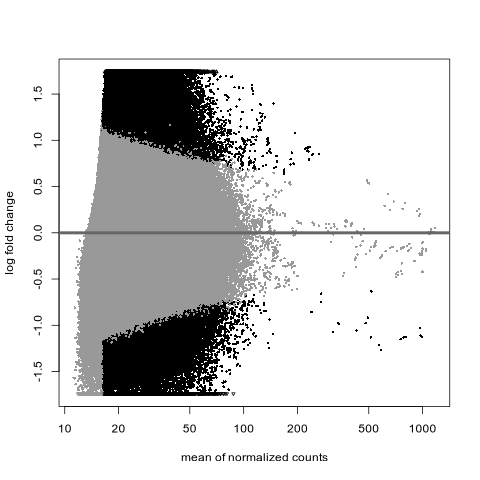

In [7]:
%%R -o enh_deseq

res_diff <- results(dds, contrast=c("Celltype", "DE", "iPSC"), alpha=0.01)
res_diff <- lfcShrink(dds, contrast=c("Celltype", "DE", "iPSC"), res=res_diff, type="ashr")

enh_deseq <- as.data.frame(res_diff)

summary(res_diff)
plotMA(res_diff, colSig = "black")

In [8]:
enhancers = pd.merge(enh_df, enh_deseq, left_index=True, right_index=True)
enhancers = enhancers.sort_values(by="padj")

# Add columns necessary for plotting
enhancers["EnhancerIDs"] = enhancers.index
enhancers["-log10(adjusted P-value)"] = enhancers["padj"].apply(lambda x: -np.log10(x) if x > 0 else 0)
enhancers["LogBaseMean"] = np.log10(enhancers["baseMean"])
enhancers["Strand"] = "+"
enhancers["."] = "."

# Replace inf with max value and remove nan rows
max_value = enhancers["-log10(adjusted P-value)"].replace([np.inf], np.nan).max()
enhancers["-log10(adjusted P-value)"].replace([np.inf], max_value, inplace=True)
enhancers.dropna(inplace=True)

display(enhancers)

/tmp/ipykernel_2846744/3853035447.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  enhancers["-log10(adjusted P-value)"].replace([np.inf], max_value, inplace=True)


,Chr,Start,End,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-d1,...,baseMean,log2FoldChange,lfcSE,pvalue,padj,EnhancerIDs,-log10(adjusted P-value),LogBaseMean,Strand,.
1786237-1786246,18,22161752,22163371,0,0,0,13,6,10,103,...,55.555774,3.333232e+00,0.375075,4.320642e-24,6.179192e-18,1786237-1786246,1.720907e+01,1.744729,+,.
1786238-1786247,18,22161912,22163670,0,0,0,16,11,13,114,...,60.158255,3.031744e+00,0.336449,2.160530e-23,1.544947e-17,1786238-1786247,1.681109e+01,1.779295,+,.
1786236-1786245,18,22161695,22163365,0,0,0,14,7,10,92,...,51.994038,3.145082e+00,0.364926,2.448308e-22,1.167154e-16,1786236-1786245,1.593287e+01,1.715954,+,.
110212-110221,1,48067933,48069380,0,1,0,3,14,5,93,...,52.025362,3.503066e+00,0.426797,3.751688e-22,1.228241e-16,110212-110221,1.591072e+01,1.716215,+,.
2345166-2345175,2,218998692,218999751,3,0,4,23,14,10,89,...,59.421279,2.827190e+00,0.318994,4.294082e-22,1.228241e-16,2345166-2345175,1.591072e+01,1.773942,+,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2217966-2217975,2,122020131,122023030,0,2,2,24,23,21,12,...,17.815496,1.559595e-06,0.293134,9.999935e-01,9.999963e-01,2217966-2217975,1.605880e-06,1.250798,+,.
136051-136060,1,70375830,70377327,3,0,0,34,24,23,23,...,20.748676,-1.358858e-06,0.279467,9.999942e-01,9.999963e-01,136051-136060,1.593815e-06,1.316990,+,.
1442741-1442750,16,4620269,4621332,6,3,1,22,28,14,11,...,16.522822,-1.028955e-06,0.301648,9.999958e-01,9.999972e-01,1442741-1442750,1.234810e-06,1.218084,+,.
4294379-4294388,9,19181256,19183210,0,1,0,26,28,17,23,...,18.223943,2.812970e-07,0.297814,9.999988e-01,9.999995e-01,4294379-4294388,2.021550e-07,1.260642,+,.


In [9]:
enhancers["Category"] = np.select([(enhancers["padj"] < 0.05) & (enhancers["log2FoldChange"] >= 1), 
                                   (enhancers["padj"] < 0.05) & (enhancers["log2FoldChange"] <= -1)], 
                                   ["DE", "iPSC"], default="Not significant")
nr_windows = enhancers["Category"].value_counts().to_dict()
print(nr_windows)

{'Not significant': 1354608, 'DE': 56498, 'iPSC': 19050}


## Figure S9b: Volcano plot of DDM enhancers

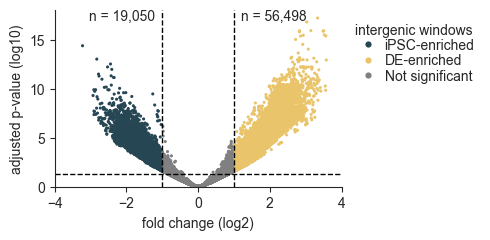

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(5, 2.5))

# Volcano plot
volcano_palette = {"iPSC": palette["iPSC"], "DE": palette["DE"], "Not significant": "gray"}
sns.scatterplot(data=enhancers[::-1], x="log2FoldChange", y="-log10(adjusted P-value)", hue="Category",
                marker="o", s=5, linewidth=0, legend=True, palette=volcano_palette, ax=axes)

# Add axis labels and threshold lines
axes.set(xlabel="fold change (log2)", ylabel="adjusted p-value (log10)", yticks=[0,5,10,15])
axes.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
axes.axvline(1, color="black", linestyle="--", linewidth=1)
axes.axvline(-1, color="black", linestyle="--", linewidth=1)

# Add legend
handles, labels = axes.get_legend_handles_labels()
axes.legend([handles[i] for i in [1,2,0]], ["iPSC-enriched", "DE-enriched", "Not significant"], 
            loc="upper left", bbox_to_anchor=(1, 1), title="intergenic windows", frameon=False, 
            markerscale=2, handletextpad=0.2, labelspacing=0.1)

# Add number of significant bins
plt.text(-1.2, 17, f"n = {nr_windows['iPSC']:,}", ha="right")
plt.text(1.2, 17, f"n = {nr_windows['DE']:,}", ha="left")

# Set axes ranges
axes.set(xlim=(-4, 4), ylim=(0, 18))

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure9b.svg", format="svg")
plt.show()

## Figure 4b. Bed files with enhancer regions

In [11]:
sign = {"iPSC": -1, "DE": 1}
celltype_enhs = {}

for celltype in ["iPSC", "DE"]:
    celltype_enh = enhancers[enhancers["Category"] == celltype]
    celltype_enh = celltype_enh.sort_values(by=["Chr", "Start"], ascending=True)
    celltype_enh = celltype_enh[["Chr", "Start", "End", "EnhancerIDs", ".", "Strand"]]
    celltype_enh = BedTool.from_dataframe(celltype_enh).sort().merge(c=[4], o=["collapse"]) # merge overlapping enhancer regions
    celltype_enh = celltype_enh.to_dataframe()
    #celltype_enh = celltype_enh[["Chr", "Start", "End", "EnhancerIDs"]]
    celltype_enh.columns = ["chrom", "start", "end", "name"]
    celltype_enh[["chrom", "start", "end"]].to_csv(f"{output_dir}/Enhancers.{celltype}.bed", sep="\t", header=False, index=False)
    display(celltype_enh)

    celltype_enhs[celltype] = celltype_enh

,chrom,start,end,name
0,1,1365911,1368555,3523-3532
1,1,6240809,6241845,17446-17455
2,1,6242047,6243155,"17459-17468,17460-17469,17461-17470,17462-1747..."
3,1,6715798,6717621,"17771-17780,17773-17782"
4,1,6751445,6753793,"17936-17945,17937-17946"
...,...,...,...,...
3944,Y,15298553,15300593,"4775511-4775520,4775512-4775521"
3945,Y,15423973,15425920,4775872-4775881
3946,Y,15438812,15443635,"4775909-4775918,4775910-4775919,4775911-477592..."
3947,Y,17234661,17237966,"4780365-4780374,4780367-4780376"


,chrom,start,end,name
0,1,923338,924692,"2453-2462,2454-2463,2455-2464,2456-2465"
1,1,984188,985891,"2477-2486,2478-2487"
2,1,1003368,1006202,"2600-2609,2602-2611,2604-2613,2605-2614,2606-2..."
3,1,1127047,1128284,"2852-2861,2853-2862,2854-2863,2855-2864,2856-2..."
4,1,1145697,1146155,2952-2961
...,...,...,...,...
9616,Y,16259011,16263685,"4777975-4777984,4777976-4777985,4777977-477798..."
9617,Y,16321779,16326312,"4778126-4778135,4778127-4778136,4778128-4778137"
9618,Y,17344998,17346702,4780603-4780612
9619,Y,17587786,17592926,"4781287-4781296,4781288-4781297,4781289-478129..."


## Figure S9c: Heatmap with DCM scores

In [12]:
# From merged regions, select top window (with lowest p-value)
top_windows = []
for celltype in ["iPSC", "DE"]:
    for index, row in celltype_enhs[celltype].iterrows():
        windows = enhancers.loc[row["name"].split(",")]
        top_window = windows.loc[windows["padj"].idxmin()].copy()
        top_window["Category"] = celltype
        top_window["ID"] = f"{row['chrom']}.{row['start']}.{row['end']}"
        top_windows.append(top_window)

top_windows_df = pd.DataFrame(top_windows)
display(top_windows_df)

,Chr,Start,End,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-d1,...,lfcSE,pvalue,padj,EnhancerIDs,-log10(adjusted P-value),LogBaseMean,Strand,.,Category,ID
3523-3532,1,1365911,1368555,5,0,2,69,41,37,15,...,0.411833,5.600626e-04,0.010411,3523-3532,1.982527,1.405336,+,.,iPSC,1.1365911.1368555
17446-17455,1,6240809,6241845,1,0,1,93,89,76,21,...,0.321172,3.890796e-05,0.001456,17446-17455,2.836983,1.674905,+,.,iPSC,1.6240809.6241845
17462-17471,1,6242558,6243098,0,2,0,115,67,51,5,...,0.404316,8.816893e-09,0.000002,17462-17471,5.620617,1.536110,+,.,iPSC,1.6242047.6243155
17771-17780,1,6715798,6717338,18,12,18,75,44,38,13,...,0.399534,3.472757e-04,0.007373,17771-17780,2.132338,1.432525,+,.,iPSC,1.6715798.6717621
17936-17945,1,6751445,6753432,1,0,0,74,38,44,14,...,0.404983,4.116387e-04,0.008336,17936-17945,2.079035,1.433439,+,.,iPSC,1.6751445.6753793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4777977-4777986,Y,16259168,16263543,0,1,0,7,13,12,36,...,0.466782,1.752363e-05,0.000802,4777977-4777986,3.095745,1.335749,+,.,DE,Y.16259011.16263685
4778127-4778136,Y,16322310,16326200,0,0,0,8,11,11,23,...,0.465143,3.689821e-05,0.001399,4778127-4778136,2.854334,1.281398,+,.,DE,Y.16321779.16326312
4780603-4780612,Y,17344998,17346702,0,2,0,19,5,7,22,...,0.488576,2.581535e-04,0.005943,4780603-4780612,2.226019,1.232971,+,.,DE,Y.17344998.17346702
4781287-4781296,Y,17587786,17590529,0,0,1,6,9,11,31,...,0.502258,8.206625e-05,0.002549,4781287-4781296,2.593625,1.239879,+,.,DE,Y.17587786.17592926


In [13]:
# Get correction factors
stats = pd.read_csv("../GEO_data/GSE304236_MeD-seq.statistics.txt", sep="\t", header=0, index_col=0)

# Normalize raw counts to DCM scores
for sample in top_windows_df.columns:
    if sample in stats.index:
        correction = stats.loc[sample, "Correction factor"]
        top_windows_df[sample] = top_windows_df[sample] / correction

# Calculate average DCM scores
top_windows_df["iPSC.nodox"] = top_windows_df[["C4neg-1", "C4neg-2", "C4neg-3"]].mean(axis=1)
top_windows_df["iPSC.dox"] = top_windows_df[["C4-1", "C4-2", "C4-3"]].mean(axis=1)
top_windows_df["DE.dox"] = top_windows_df[["DE-d1", "DE-d2", "DE-d3"]].mean(axis=1)
top_windows_df["iPSC.chase"] = top_windows_df[["iPSC-c1", "iPSC-c2", "iPSC-c3"]].mean(axis=1)
top_windows_df["DE.chase"] = top_windows_df[["DE-c1", "DE-c2", "DE-c3"]].mean(axis=1)
top_windows_df["PGT.chase"] = top_windows_df[["PGT-c1", "PGT-c2", "PGT-c3"]].mean(axis=1)

display(top_windows_df)

top_windows_df.to_csv(f"{output_dir}/Enhancer_counts.txt", sep="\t", header=True, index=True)

,Chr,Start,End,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-d1,...,Strand,.,Category,ID,iPSC.nodox,iPSC.dox,DE.dox,iPSC.chase,DE.chase,PGT.chase
3523-3532,1,1365911,1368555,0.117884,0.000000,0.057258,1.247554,0.946343,1.032392,0.499537,...,+,.,iPSC,1.1365911.1368555,0.058381,1.075430,0.405527,0.607931,1.089557,0.504653
17446-17455,1,6240809,6241845,0.023577,0.000000,0.028629,1.681486,2.054256,2.120589,0.699352,...,+,.,iPSC,1.6240809.6241845,0.017402,1.952110,0.798419,0.598845,1.836747,1.130141
17462-17471,1,6242558,6243098,0.000000,0.061264,0.000000,2.079257,1.546462,1.423027,0.166512,...,+,.,iPSC,1.6242047.6243155,0.020421,1.682915,0.318678,0.624685,1.386072,0.662182
17771-17780,1,6715798,6717338,0.424381,0.367584,0.515321,1.356037,1.015587,1.060295,0.432932,...,+,.,iPSC,1.6715798.6717621,0.435762,1.143973,0.433389,2.932109,2.544488,1.249062
17936-17945,1,6751445,6753432,0.023577,0.000000,0.000000,1.337957,0.877098,1.227710,0.466235,...,+,.,iPSC,1.6751445.6753793,0.007859,1.147588,0.432023,0.000000,0.357043,0.329312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4777977-4777986,Y,16259168,16263543,0.000000,0.030632,0.000000,0.126563,0.300060,0.334830,1.198890,...,+,.,DE,Y.16259011.16263685,0.010211,0.253818,1.013831,0.046546,0.123621,0.379567
4778127-4778136,Y,16322310,16326200,0.000000,0.000000,0.000000,0.144644,0.253897,0.306927,0.765957,...,+,.,DE,Y.16321779.16326312,0.000000,0.235156,0.883734,0.102178,0.183846,0.326697
4780603-4780612,Y,17344998,17346702,0.000000,0.061264,0.000000,0.343529,0.115408,0.195317,0.732655,...,+,.,DE,Y.17344998.17346702,0.020421,0.218085,0.784585,0.111264,0.000000,0.505960
4781287-4781296,Y,17587786,17590529,0.000000,0.000000,0.028629,0.108483,0.207734,0.306927,1.032377,...,+,.,DE,Y.17587786.17592926,0.009543,0.207715,0.808330,0.055632,0.062818,0.578556


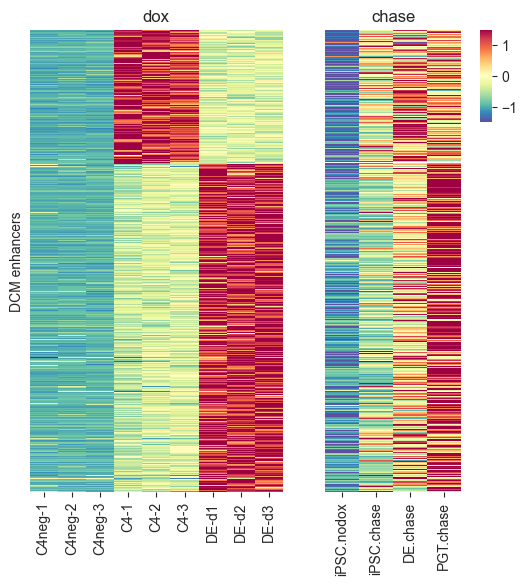

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(6,6), sharey=True, width_ratios=(3,2))

# Heatmap with dox replicates
dox_df = top_windows_df[["C4neg-1", "C4neg-2", "C4neg-3", "C4-1", "C4-2", "C4-3", "DE-d1", "DE-d2", "DE-d3"]].apply(scipy.stats.zscore, axis=1)
sns.heatmap(dox_df, ax=axes[0], xticklabels=1, yticklabels=False, 
            cmap="Spectral_r", center=0, vmin=-1.5, vmax=1.5, cbar=False)
axes[0].set_title("dox")
axes[0].set_ylabel("DCM enhancers")

# Heatmap with averages of chase samples
chase_df = top_windows_df[["iPSC.nodox", "iPSC.chase", "DE.chase", "PGT.chase"]].apply(scipy.stats.zscore, axis=1)
hm = sns.heatmap(chase_df, ax=axes[1], xticklabels=1, yticklabels=False,
                 cmap="Spectral_r", center=0, vmin=-1.5, vmax=1.5, cbar=False)
axes[1].set_title("chase")
axes[1].set_ylabel("")

# Add colorbar
cbar = fig.colorbar(hm.get_children()[0], ax=axes[1], location="right", shrink=0.2, aspect=8, anchor=(0.8, 1))
cbar.outline.set_visible(False)

plt.savefig(f"{output_dir}/SupplementalFigure6e.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S9d: Boxplot with DCM scores

In [15]:
boxplot_df = top_windows_df[["iPSC.nodox", "iPSC.dox", "DE.dox", "iPSC.chase", "DE.chase", "PGT.chase", "Category"]]

stats_results = {}
for sample in boxplot_df.columns[:-1]:
    iPSC_values = boxplot_df.loc[boxplot_df["Category"] == "iPSC", sample]
    DE_values = boxplot_df.loc[boxplot_df["Category"] == "DE", sample]
    stat, p_value = mannwhitneyu(iPSC_values, DE_values, alternative="two-sided")
    stats_results[sample] = p_value

# P-values between iPSC and DE enhancers
stats_df = pd.DataFrame.from_dict(stats_results, orient="index", columns=["p-value"])
stats_df["adj p-value"] = multipletests(stats_df["p-value"], method="bonferroni")[1]
print(stats_df)

# Melted dataframe for plotting
melted_df = boxplot_df.melt(id_vars=["Category"], var_name="Sample", value_name="DCM score")
melted_df["Sample"] = melted_df["Sample"].str.replace(".", " ")
display(melted_df)

                  p-value    adj p-value
iPSC.nodox   2.934320e-02   1.760592e-01
iPSC.dox     0.000000e+00   0.000000e+00
DE.dox       0.000000e+00   0.000000e+00
iPSC.chase   3.114610e-72   1.868766e-71
DE.chase     7.706851e-24   4.624111e-23
PGT.chase   6.425201e-255  3.855121e-254


,Category,Sample,DCM score
0,iPSC,iPSC nodox,0.058381
1,iPSC,iPSC nodox,0.017402
2,iPSC,iPSC nodox,0.020421
3,iPSC,iPSC nodox,0.435762
4,iPSC,iPSC nodox,0.007859
...,...,...,...
81415,DE,PGT chase,0.379567
81416,DE,PGT chase,0.326697
81417,DE,PGT chase,0.505960
81418,DE,PGT chase,0.578556


/tmp/ipykernel_2846744/3241337683.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


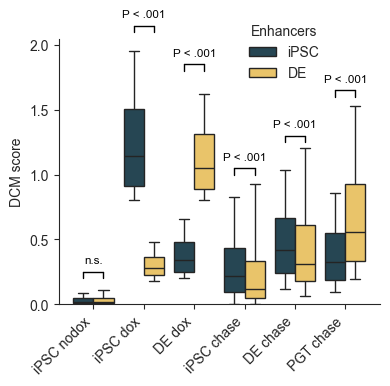

In [16]:
fig, ax = plt.subplots(figsize=(4, 4))

sns.boxplot(data=melted_df, x="Sample", y="DCM score", hue="Category", showfliers=False, 
            palette=palette, saturation=1, whis=[10, 90], ax=ax)
# sns.violinplot(data=melted_df, x="Sample", y="DCM score", hue="Category", palette=palette, saturation=1, split=True,
#                inner="quart", ax=ax, width=3)
# ax.set_ylim(0, 2.2)

ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(frameon=False, title="Enhancers", bbox_to_anchor=(0.85, 1.1))

ax.set_ylim(0, None)
ax.set_yticks([0, 0.5, 1, 1.5, 2])

# Add p-values
xlen = 0.2   # half of length horizontal line
ylen = 0.05  # length of vertical line
for axis, x, y, label in [[ax, 0, 0.2, "n.s."], [ax, 1, 2.1, "P < .001"], [ax, 2, 1.8, "P < .001"], 
                          [ax, 3, 1, "P < .001"], [ax, 4, 1.25, "P < .001"], [ax, 5, 1.6, "P < .001"]]:
    axis.plot((x-xlen, x+xlen), (y+ylen, y+ylen), color="black", linewidth=1, clip_on=False)  # horizontal line
    axis.plot((x-xlen, x-xlen), (y, y+ylen), color="black", linewidth=1, clip_on=False)       # left vertical line
    axis.plot((x+xlen, x+xlen), (y, y+ylen), color="black", linewidth=1, clip_on=False)       # right vertical line
    axis.text(x, y+ylen*2, label, ha="center", va="bottom", color="black", fontsize="small")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure6f.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure 4d. Enriched motifs at enhancer regions

In [17]:
# HOMER motif enrichment results: keys = dataset labels, values = output directories
motif_dir = f"{output_dir}/Motifs"
motif_datasets = {"Enh iPSC>DE": "Enhancers.iPSC_vsDE", "Enh DE>iPSC": "Enhancers.DE_vsiPSC",
              "H3K27ac iPSC>DE": "H3K27ac.iPSC_vsDE", "H3K27ac DE>iPSC": "H3K27ac.DE_vsiPSC"}

# Load and merge motif results
dfs_logp = {}
dfs_pct = {}
for label, subdir in motif_datasets.items():
    df = pd.read_csv(f"{motif_dir}/{subdir}/knownResults.txt", sep="\t")
    df = df.rename(columns={df.columns[0]: "Motif"})
    df["Motif"] = df["Motif"].str.replace(r"\(.*\)", "", regex=True).str.replace(r"/Homer$", "", regex=True).str.strip().str.upper()
    df["Padj"] = multipletests(df["P-value"], method="bonferroni")[1]
    df["-log10p"] = -np.log10(df["Padj"])
    pct_col = [c for c in df.columns if "% of Target" in c][0]
    df["pct_target"] = df[pct_col].astype(str).str.rstrip("%").astype(float)
    idx = df.groupby("Motif", sort=False)["-log10p"].idxmax()
    df_best = df.loc[idx].set_index("Motif")
    dfs_logp[label] = df_best["-log10p"].rename(label)
    dfs_pct[label] = df_best["pct_target"].rename(label)
matrix = pd.concat(dfs_logp.values(), axis=1, join="outer").fillna(0)
matrix_pct = pd.concat(dfs_pct.values(), axis=1, join="outer").fillna(0)

# Select top motifs to plot
motifs_ipsc_de = list(matrix["Enh iPSC>DE"][matrix["Enh iPSC>DE"] > -np.log10(0.05)].nlargest(12).index)
motifs_de_ipsc = list(matrix["Enh DE>iPSC"][matrix["Enh DE>iPSC"] > -np.log10(0.05)].nlargest(12).index)
top_motifs = motifs_ipsc_de + motifs_de_ipsc
top_matrix = matrix.loc[top_motifs]
top_matrix_pct = matrix_pct.loc[top_motifs]
display(top_matrix)

,Enh iPSC>DE,Enh DE>iPSC,H3K27ac iPSC>DE,H3K27ac DE>iPSC
Motif,,,,
OCT4-SOX2-TCF-NANOG,22.356547,-0.000000,169.356547,-0.000000
OCT4,7.356547,-0.000000,69.356547,-0.000000
OCT11,3.356547,-0.000000,53.356547,-0.000000
OCT2,2.356547,-0.000000,35.356547,-0.000000
OCT6,1.356547,-0.000000,53.356547,-0.000000
ZFP281,1.356547,-0.000000,-0.000000,2.356547
GATA2,-0.000000,73.356547,-0.000000,17.356547
GATA1,-0.000000,67.356547,-0.000000,17.356547
GATA3,-0.000000,66.356547,1.356547,22.356547


In [18]:
# DCM scores
dcm = pd.read_csv(f"{input_dir}/GSE304236_DCMscores.genes.txt", sep="\t", index_col=0, header=0)
dcm = dcm[dcm["GeneName"] != "."]
dcm.index = dcm["GeneName"].str.upper()
dcm = dcm[~dcm.index.duplicated(keep="first")]
display(dcm)

# DCM scores for TFs with enriched motifs
gene_aliases = {"OCT4-SOX2-TCF-NANOG": ["POU5F1", "SOX2", "TCF7L1", "NANOG"], "OCT4": "POU5F1", "OCT1": "POU2F1", "OCT2": "POU2F2", 
           "OCT6": "POU3F1", "OCT11": "POU2F3", "ZFP281": "ZNF281", "ZFP809": "ZNF809", "BRN1": "POU3F3", "PIT1": "POU1F1", 
           "TBET": "TBX21", "EBF": "EBF1"}
dcm_cols = ["iPSC_nodox", "iPSC_dox", "DE_dox"]

def dcm_lookup_row(tf):
    target = gene_aliases.get(tf, tf)
    if isinstance(target, list):
        genes = [g for g in target if g in dcm.index]
        dcm_row = dcm.loc[genes][dcm_cols].mean(axis=0) if genes else pd.Series(np.nan, index=dcm_cols)
    else:
        dcm_row = dcm.loc[target][dcm_cols] if target in dcm.index else pd.Series(np.nan, index=dcm_cols)
    return dcm_row

dcm_tfs = pd.DataFrame([dcm_lookup_row(tf) for tf in top_matrix.index], index=top_matrix.index)
dcm_tfs = dcm_tfs.apply(lambda row: scipy.stats.zscore(row.astype(float), nan_policy="omit"), axis=1)
display(dcm_tfs)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,C6neg-1,C6neg-2,C6neg-3,C6-1,...,T48,T72,iPSC_nodox,iPSC_chase,iPSC_dox,DE_chase,DE_dox,PGT_chase,GeneName,NrSites
GeneName,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000620,0.001612,0.003014,0.042822,0.039482,0.048462,0.001442,0.000000,0.000000,0.046142,...,0.000000,0.000000,0.001749,0.006315,0.043589,0.018845,0.048050,0.012696,TSPAN6,38
TNMD,0.000575,0.000000,0.000000,0.038807,0.034341,0.040833,0.000000,0.001415,0.000705,0.033411,...,0.039010,0.000000,0.000192,0.003627,0.037994,0.008884,0.023858,0.005416,TNMD,41
DPM1,0.004438,0.005045,0.002021,0.103165,0.083093,0.087647,0.004512,0.002730,0.003061,0.086059,...,0.018816,0.000000,0.003835,0.032069,0.091302,0.045974,0.055403,0.055444,DPM1,85
SCYL3,0.001331,0.003211,0.002309,0.051179,0.057704,0.045904,0.002651,0.002339,0.003963,0.047282,...,0.000000,0.000000,0.002284,0.014743,0.051596,0.023948,0.051521,0.034199,SCYL3,124
C1ORF112,0.001804,0.002180,0.002140,0.035357,0.040372,0.042450,0.002047,0.001703,0.002777,0.037439,...,0.005692,0.015669,0.002041,0.013985,0.039393,0.022678,0.036709,0.026909,C1orf112,562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FLJ43315,0.005125,0.003552,0.006016,0.011661,0.020573,0.023050,0.007146,0.005465,0.005446,0.013897,...,0.011590,0.000000,0.004898,0.071054,0.018428,0.079650,0.017818,0.049337,FLJ43315,138
LGALS17A,0.000000,0.000988,0.000000,0.014581,0.011913,0.016201,0.000000,0.002807,0.002797,0.005303,...,0.000000,0.000000,0.000329,0.005571,0.014232,0.027339,0.014810,0.009569,LGALS17A,31
ZNF883,0.001846,0.002214,0.001380,0.027012,0.034622,0.032945,0.001320,0.000524,0.001045,0.026077,...,0.018129,0.000000,0.001813,0.003498,0.031526,0.015868,0.021577,0.018440,ZNF883,166


,iPSC_nodox,iPSC_dox,DE_dox
Motif,,,
OCT4-SOX2-TCF-NANOG,-1.255516,1.191460,0.064056
OCT4,-1.276333,1.165642,0.110690
OCT11,-1.412182,0.771720,0.640462
OCT2,-1.353182,1.032504,0.320678
OCT6,-1.394622,0.900465,0.494158
ZFP281,-1.394022,0.903233,0.490789
GATA2,-1.379453,0.419851,0.959601
GATA1,-1.132664,-0.167019,1.299683
GATA3,-1.194262,-0.058845,1.253107


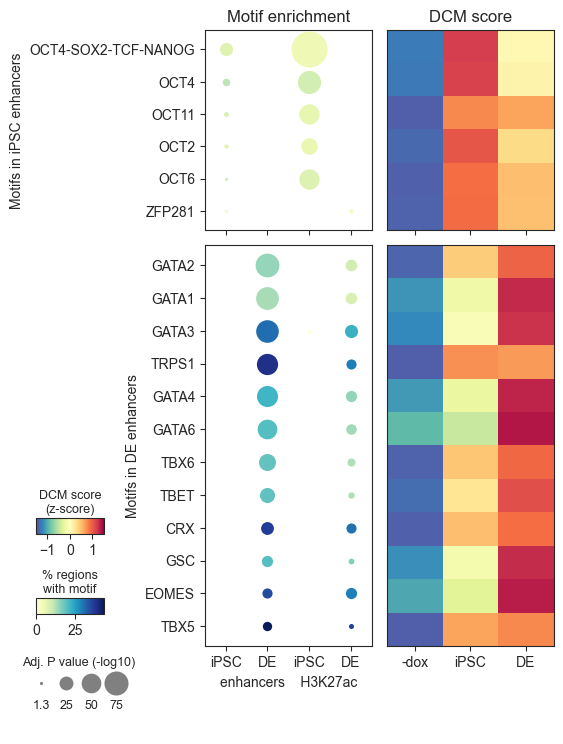

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(4.5, 8), gridspec_kw={"width_ratios": [4, 0.1, 4], 
                         "height_ratios": [len(motifs_ipsc_de), len(motifs_de_ipsc)], "hspace": 0.05, "wspace": 0.05})
ax1a, _, ax2a = axes[0]
ax1b, ax_gap, ax2b = axes[1]
ax_gap.axis("off")
axes[0, 1].axis("off")  # also hide the top gap cell

# Left: motif enrichment dotplot (size = -log10 adj. p-value, color = % targets with motif)
pct_norm = matplotlib.colors.Normalize(vmin=0, vmax=top_matrix_pct.values.max())
cmap_pct = plt.cm.YlGnBu
sm1 = matplotlib.cm.ScalarMappable(cmap=cmap_pct, norm=pct_norm)
sm1.set_array([])

def draw_dotplot(ax, motif_list):
    sub = top_matrix.loc[motif_list]
    sub_pct = top_matrix_pct.loc[motif_list]
    for i, motif in enumerate(sub.index):
        for j, col in enumerate(sub.columns):
            logp = sub.loc[motif, col]
            pct = sub_pct.loc[motif, col]
            ax.scatter(j, i, s=logp * 4, c=[cmap_pct(pct_norm(pct))], zorder=3, linewidths=0)
    ax.set(xticks=range(len(sub.columns)), yticks=range(len(sub.index)), yticklabels=sub.index,
           xlim=(-0.5, len(sub.columns) - 0.5), ylim=(-0.6, len(sub.index) - 0.4))
    ax.invert_yaxis()

draw_dotplot(ax1a, motifs_ipsc_de)
draw_dotplot(ax1b, motifs_de_ipsc)

ax1a.set(xticklabels=[], ylabel="Motifs in iPSC enhancers", title="Motif enrichment")
ax1b.set(xticklabels=["iPSC", "DE", "iPSC", "DE"], xlabel="enhancers    H3K27ac", ylabel="Motifs in DE enhancers")

# Right: DCM scores
dcm_tfs_a = dcm_tfs.loc[motifs_ipsc_de]
dcm_tfs_b = dcm_tfs.loc[motifs_de_ipsc]
im2 = ax2a.imshow(dcm_tfs_a, aspect="auto", cmap="Spectral_r", vmin=-1.5, vmax=1.5, interpolation="nearest")
ax2a.set(xticks=range(len(dcm_cols)), xticklabels=[], yticks=[], title="DCM score")
ax2b.imshow(dcm_tfs_b, aspect="auto", cmap="Spectral_r", vmin=-1.5, vmax=1.5, interpolation="nearest")
ax2b.set(xticks=range(len(dcm_cols)), xticklabels=["-dox", "iPSC", "DE"], yticks=[])

# Colorbars
cb1 = fig.colorbar(sm1, cax=fig.add_axes([-0.25, 0.15, 0.15, 0.02]), orientation="horizontal")
cb1.set_label("% regions\nwith motif", fontsize=9)
cb1.ax.xaxis.set_label_position("top")

cb2 = fig.colorbar(im2, cax=fig.add_axes([-0.25, 0.25, 0.15, 0.02]), orientation="horizontal")
cb2.set_label("DCM score\n(z-score)", fontsize=9)
cb2.ax.xaxis.set_label_position("top")

# Size legend
ax_size = fig.add_axes([-0.28, 0.00, 0.25, 0.12])
ax_size.axis("off")
size_vals = [1.3, 25, 50, 75]
x_spacing = 0.8
for i, v in enumerate(size_vals):
    ax_size.scatter(i * x_spacing, 0.5, s=v * 4, c=["gray"], linewidths=0, zorder=3)
    ax_size.text(i * x_spacing, 0.2, str(v), ha="center", va="top", fontsize=9)
ax_size.text((len(size_vals) - 1) * x_spacing / 2, 0.75, "Adj. P value (-log10)", ha="center", va="bottom", fontsize=9)
ax_size.set_xlim(-0.6, (len(size_vals) - 1) * x_spacing + 0.6)
ax_size.set_ylim(-0.4, 1.3)

plt.savefig(f"{output_dir}/Figure4d.svg")
plt.show()